# Modeling


## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys 
sys.path.append('..')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [2]:
data = pd.read_parquet('../data/processed_data/reviews_clean.parquet')

print('Shape: ', data.shape)

Shape:  (406781, 10)


In [3]:
# data.dtypes
print('review_clean dtype: ', data['review_clean'].dtype)
print('NaN in review_clean: ', data['review_clean'].isna().sum())
print('Empty strings in review_clean: ', (data['review_clean'].str.len() == 0).sum())

review_clean dtype:  str
NaN in review_clean:  0
Empty strings in review_clean:  0


In [ ]:
print('Label balance:')
print(data['label'].value_counts(normalize=True).round(3))
print(f'\nDuplicates flagged: {data['is_duplicate'].sum():,}')
print(f'\nword_count summary:')
print(data['word_count'].describe().round(1))

## 2. Notebook scope & recap

**What this notebook does.** Topic modeling on the cleaned review corpus using the
*aggressive* vectorizer variant (game-specific stopwords, lemmatization, higher `min_df`,
duplicates dropped, short reviews filtered out). The goal is interpretable themes, so the
configuration optimizes for a clean, low-noise vocabulary rather than preserving every signal.

**Deliberately deferred to the sentiment notebook (`04`).** The *conservative* variant lives
there and shares only the base dataset with this notebook — almost every other choice differs:
- Negations (not / don't) and short reviews are **kept**, `ngram_range=(1, 2)`, lower `min_df`.
- Duplicates are **not dropped** but handled group-aware at the train/test split to avoid leakage.
- Class imbalance handling (stratification, class_weight / scale_pos_weight) and the F1 / PR-AUC
  metric choice are sentiment-only concerns.
None of that applies here — if you're reading `03` looking for sentiment logic, it's in `04`.

**Relevant decisions inherited from `02`.** The dataset is intentionally *neutral*:
- The `word_count` and `is_duplicate` flags are **not yet applied** — that happens in Section 4,
  and the choices there are specific to the topic-modeling variant.
- Only English + UNKNOWN language rows were kept; all other languages were dropped in `02`.
- `review_clean` is already HTML-unescaped, lowercased, and whitespace-normalized, with negations
  left intact. This notebook does **not** re-clean text; it only vectorizes.

## 3. Representation & model: count-based LDA vs. TF-IDF + NMF

Chosen path: **build both (LDA on counts, NMF on TF-IDF) and compare.**

- **LDA is a generative, count-based model.** It assumes each document is produced by a
  count process (a multinomial over words), so its natural input is a raw document-term
  matrix of integer frequencies — i.e. `CountVectorizer`. TF-IDF outputs weighted fractional
  values (0.31 doesn't mean "occurred 0.31 times"), which violates that assumption. sklearn's
  `LatentDirichletAllocation` runs on TF-IDF, but tends to produce fuzzier, less interpretable
  topics.
  
- **NMF is linear algebra, not a count model.** It factorizes the document-term matrix into a
  document-topic and a topic-word matrix. It has no count assumption, so TF-IDF fits well — the
  down-weighting of common words actually helps it find more distinct topics. This is the
  classical, well-behaved pairing.

So the two clean classical paths are:

| Representation              | Model | Character                                      |
|-----------------------------|-------|------------------------------------------------|
| Raw counts (`CountVectorizer`) | LDA   | probabilistically principled, the "famous" one |
| TF-IDF (`TfidfVectorizer`)     | NMF   | crisper topics on short texts, faster, stable  |

### Why both, instead of just the better-fitting one
For *this* corpus, TF-IDF + NMF is arguably the technically sounder default: reviews are short
(LDA was designed for long documents and gets shaky when there are few words per document to
estimate the topic mixture from), and there are ~400k of them (LDA is iterative and slower; NMF
is faster and reproducible across runs with a fixed init — no RNG noise between fits).

Despite that, we build **both** — this is a learning project and seeing the difference on real
data is the point. NMF is expected to give the cleaner result here; LDA serves as the contrast
that makes *why* concrete rather than theoretical. Both are classical, bag-of-words, unsupervised
topic models — the same task, differing only in the count-vs-factorization assumption. The modern
contrast (BERTopic, transformer embeddings) is deferred to the later phase, with these two as the
comparison anchor.

### Consequence for the rest of the notebook
Section 6 must build **two** vectorizers from the same cleaned, filtered corpus: a
`CountVectorizer` feeding LDA and a `TfidfVectorizer` feeding NMF. The corpus selection
(Section 4) and stopword / leakage decisions (Section 5) are **shared** — they apply identically
to both paths, so only the final vectorization step forks.

## 4. Corpus selection: applying the variant flags

In [5]:
data['word_count'].describe()

count    406781.000000
mean         42.778842
std          88.740938
min           1.000000
25%           6.000000
50%          15.000000
75%          42.000000
max        7984.000000
Name: word_count, dtype: float64

In [6]:
n_start = len(data)
n_start

406781

In [ ]:
# Filter 1: Drop duplicate reviews

data_topic = data[~data['is_duplicate']].copy()
n_after_dupes = len(data_topic)

n_after_dupes

In [8]:
# Filter 2: Drop very short reviews

MIN_WORD_COUNT = 5
data_topic = data_topic[data_topic['word_count'] >= MIN_WORD_COUNT].copy()
n_after_short = len(data_topic)

n_after_short

318442

In [9]:
print(f"Start:                 {n_start:>8,}")
print(f"After dropping dupes:  {n_after_dupes:>8,}  (-{n_start - n_after_dupes:,})")
print(f"After dropping short:  {n_after_short:>8,}  (-{n_after_dupes - n_after_short:,})")
print(f"\nRemaining corpus:      {len(data_topic):>8,}  "
      f"({len(data_topic) / n_start:.1%} of base)")

Start:                  406,781
After dropping dupes:   356,718  (-50,063)
After dropping short:   318,442  (-38,276)

Remaining corpus:       318,442  (78.3% of base)


## 5. Game dominance & leakage

In [10]:
data_topic['title'].value_counts().head(15)

title
PLAYERUNKNOWN'S BATTLEGROUNDS                  104450
Grand Theft Auto V                              72417
Rust                                            54341
Rocket League®                                  46900
Dead by Daylight                                17357
MONSTER HUNTER: WORLD                           14902
ASTRONEER                                        2406
The Elder Scrolls V: Skyrim Special Edition      1343
RESIDENT EVIL 2 / BIOHAZARD RE:2                 1005
Sid Meier’s Civilization® VI                      472
Euro Truck Simulator 2                            381
Subnautica                                        212
Terraria                                          210
Slay the Spire                                    202
ARK: Survival Evolved                             179
Name: count, dtype: int64

**DECISION** — target: **cross-game themes**. 
Strategy: **diagnose first, then treat.**

### The situation
After Section 4's filtering, the corpus is still dominated by a handful of titles
(counts on `data_topic`):

| Game                 | Reviews | Share |
|----------------------|--------:|------:|
| PUBG                 | 104,450 | 32.8% |
| Grand Theft Auto V   |  72,417 | 22.7% |
| Rust                 |  54,341 | 17.1% |
| Rocket League        |  46,900 | 14.7% |
| Dead by Daylight     |  17,357 |  5.5% |
| Monster Hunter World |  14,902 |  4.7% |
| **Top 6 combined**   | **310,367** | **97.5%** |

The 7th title (ASTRONEER) has only 2,406 reviews — a ~6x drop. The top 4 alone are 87%.
Deduplication did **not** ease this; the distribution is essentially unchanged from the EDA.

### Why this is a problem for our goal
We want **cross-game themes** ("performance / bugs", "toxic community", "value for money") —
topics that cut across titles. Per-game topics would be near-tautological here: we already
have `title` as a column, so a model that just rediscovers "these are the PUBG reviews" adds
nothing. Game dominance is therefore an adversary: with this imbalance, LDA/NMF will tend to
cluster by *game* rather than by *theme*.

### Two distinct leakage channels
1. **Name-level leakage** (rocket, pubg, rust, rockstar, …) — surface tokens that would appear
   directly as topic words. Removed via game-specific stopwords in Section 6b. (Relatively
   uncontroversial.)
2. **Vocabulary-level leakage** (Rocket League: car / ball / boost / rank; PUBG: loot /
   circle / squad / lag; Rust: base / raid / wipe) — these are NOT names, so no name-list
   catches them, yet they still cluster into a de-facto per-game topic. This is the harder,
   non-obvious channel.

### Chosen approach: diagnose first
Start with **only the name-level stopwords** , fit both models, and inspect the
topics in Section 9. Then decide whether the vocabulary-level leakage needs treatment, and how
much, based on what we actually observe — rather than pre-configuring against an assumed problem.

Options held in reserve for after the Section-9 diagnosis:
- **B — subsample dominant titles** (cap each game at N reviews) to fight volume dominance.
  Cost: discards real data; N is arbitrary; the doc-topic matrix would then cover only the
  sample, requiring a later `transform` pass for the rest.
- **C — extend stopwords to the semantic field.** Cost: hard to draw the line cleanly
  ("ball" is RL jargon but also a normal word); risks removing genuine signal.

**Expectation, stated up front:** given the 87% top-4 share, the first pass will *likely* show
game-flavored topics. That is the diagnostic finding we want — not a failure. It tells us how
much treatment (B/C) the next iteration needs.

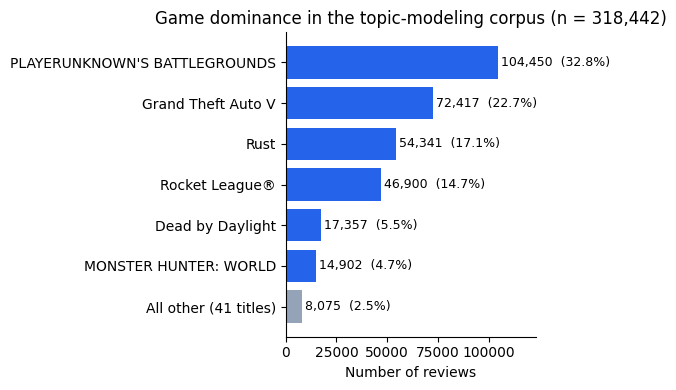

In [11]:
# Visualizing the game dominance
# We plot the top titles individually and collapse everything else into a single "rest" bar,
# so the long tail of minor games doesn't make the chart unreadable.


TOP_N = 6  # plot the dominant titles individually; collapse the remainder into one bar

counts = data_topic['title'].value_counts()
top = counts.head(TOP_N)
rest_total = counts.iloc[TOP_N:].sum()
rest_label = f"All other ({len(counts) - TOP_N} titles)"

# Assemble plot data: top titles + a single collapsed "rest" bar.
plot_counts = pd.concat([top, pd.Series({rest_label: rest_total})])

# Share of the corpus for annotation.
plot_share = plot_counts / len(data_topic)

# %%
fig, ax = plt.subplots(figsize=(6, 4))

# Reverse order so the largest bar sits at the top (barh stacks bottom-up).
y = plot_counts[::-1]
shares = plot_share[::-1]

# Grey out the collapsed "rest" bar to set it apart from the real titles.
colors = ['#94a3b8' if label == rest_label else '#2563eb' for label in y.index]

bars = ax.barh(y.index, y.values, color=colors)

# Annotate each bar with count + percentage.
for bar, share in zip(bars, shares.values):
    width = bar.get_width()
    ax.text(width + len(data_topic) * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{int(width):,}  ({share:.1%})",
            va='center', ha='left', fontsize=9)

ax.set_xlabel("Number of reviews")
ax.set_title(f"Game dominance in the topic-modeling corpus (n = {len(data_topic):,})")
ax.set_xlim(0, top.iloc[0] * 1.18)  # headroom for the annotations
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Vectorizer

### 6.1 Lemmatization

In [ ]:
import spacy

LEMMA_PATH = '../data/processed_data/reviews_lemmatized.parquet'

nlp = spacy.load('en_core_web_sm', disable = ['parser', 'ner'])

In [ ]:
def lemmatize_text(doc):
    return ' '.join(token.lemma_.lower() for token in doc)


if os.path.exists(LEMMA_PATH):
    # Cache
    print("Loading cached lemmas from disk.")
    data_topic['review_lemmatized'] = pd.read_parquet(LEMMA_PATH)['review_lemmatized']
else:
    # No cache - run spaCy (slow on CPU: ~320k docs)
    print("No cache — running spaCy...")
    lemmas = [lemmatize_text(doc)
              for doc in tqdm(nlp.pipe(data_topic['review_clean'], batch_size = 500),
                              total = len(data_topic), desc = 'Lemmatizing')]
    data_topic['review_lemmatized'] = lemmas
    data_topic[['review_lemmatized']].to_parquet(LEMMA_PATH)
    print(f"Saved to {LEMMA_PATH}")

In [ ]:
# nlp stays loaded: its stop_words list is reused for the stopword set in Section 6.2

In [15]:
print('Before/After (first 3 rows):\n')
for before, after in zip(data_topic['review_clean'].head(3),
                         data_topic['review_lemmatized'].head(3)):
    print(f' RAW:   {before[:80]}')
    print(f' LEMMA: {after[:80]}\n')

empty_after = (data_topic['review_lemmatized'].str.len() == 0).sum()

print(f'Rows that became empty after lemmatization: {empty_after}')

Before/After (first 3 rows):

 RAW:   > played as german reich> declare war on belgium> can't break belgium so go thro
 LEMMA: > play as german reich > declare war on belgium > can not break belgium so go th

 RAW:   very good game although a bit overpriced in my opinion. i'd prefer playing the g
 LEMMA: very good game although a bit overpriced in my opinion . i would prefer play the

 RAW:   out of all the reviews i wrote this one is probably the most serious one i wrote
 LEMMA: out of all the review i write this one be probably the most serious one i write 

Rows that became empty after lemmatization: 0


### 6.2 Stopwords

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

In [17]:
diag_vectorizer = CountVectorizer()
diag_dtm = diag_vectorizer.fit_transform(data_topic['review_lemmatized'])

vocab = diag_vectorizer.get_feature_names_out()
term_freq = np.asarray(diag_dtm.sum(axis = 0)).ravel()

print(f'Raw vocab size (no filtering): {len(vocab):,}')

Raw vocab size (no filtering): 174,106


In [18]:
TOP_K = 30

top_idx = np.argsort(term_freq)[-TOP_K:][::-1]
top_terms = vocab[top_idx]
top_counts = term_freq[top_idx]

game_name_tokens = {
    'pubg', 'playerunknown', 'battleground', 'battlegrounds',
    'gta', 'grand', 'theft', 'auto', 'rockstar',
    'rust', 'rocket', 'league',
    'dead', 'daylight', 'monster', 'hunter', 'world',
}

In [19]:
# print(type(top_idx), getattr(top_idx, 'shape', 'kein shape'))
# print(TOP_K)

In [20]:
# print(type(term_freq), getattr(term_freq, 'shape', 'kein shape'))
# print(type(top_counts), getattr(top_counts, 'shape', 'kein shape'))

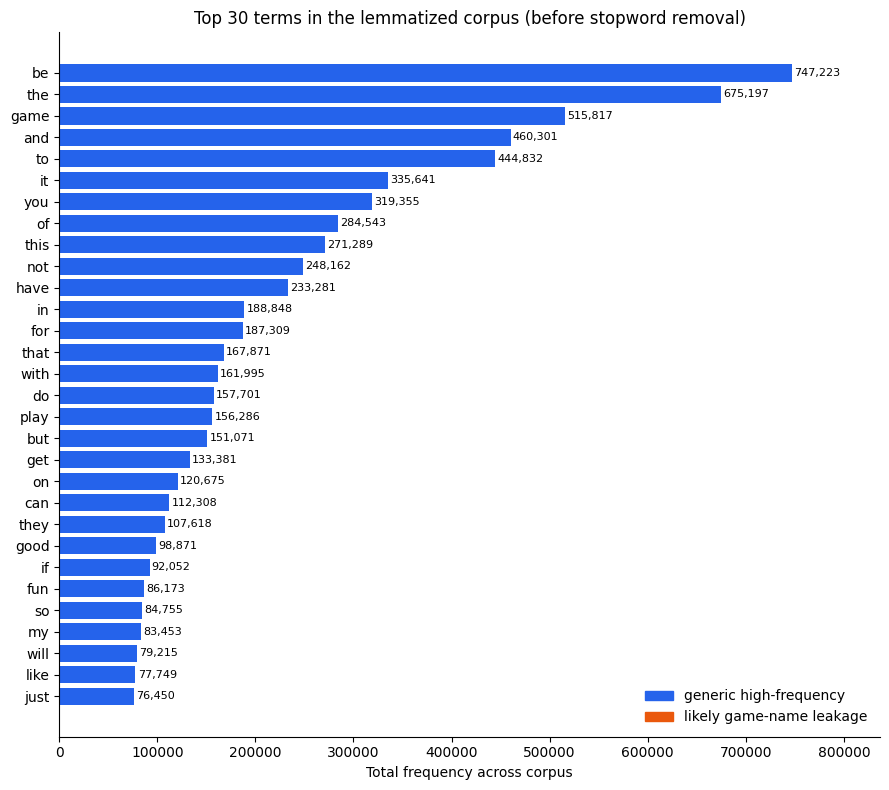

In [21]:
fig, ax = plt.subplots(figsize = (9,8))

terms_r = top_terms[::-1]
counts_r = top_counts[::-1]

colors = ['#ea580c' if t in game_name_tokens else '#2563eb' for t in terms_r]

bars = ax.barh(terms_r, counts_r, color=colors)
for bar in bars:
    w = bar.get_width()
    ax.text(w + term_freq.max() * 0.003, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va='center', ha='left', fontsize=8)

ax.set_xlabel("Total frequency across corpus")
ax.set_title(f"Top {TOP_K} terms in the lemmatized corpus (before stopword removal)")
ax.set_xlim(0, top_counts[0] * 1.12)
ax.spines[['top', 'right']].set_visible(False)

# Legend via proxy handles.
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2563eb', label='generic high-frequency'),
                   Patch(color='#ea580c', label='likely game-name leakage')],
          loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
stopwords = set(nlp.Defaults.stop_words)
stopwords |= {'game', 'play', 'player'}

print(f'Stopwords list size: {len(stopwords)}')

In [23]:
#  Diagnostic vectorizer now WITH stopwords. The generic words are gone,
# so game-specific terms should rise to the top and become visible.

diag_vectorizer2 = CountVectorizer(stop_words=list(stopwords))
diag_dtm2 = diag_vectorizer2.fit_transform(data_topic['review_lemmatized'])

vocab2 = diag_vectorizer2.get_feature_names_out()
term_freq2 = np.asarray(diag_dtm2.sum(axis=0)).flatten()

TOP_K = 30
top_idx2 = np.argsort(term_freq2)[-TOP_K:][::-1]
top_terms2 = vocab2[top_idx2]
top_counts2 = term_freq2[top_idx2]

print(f"Vocabulary after stopwords: {len(vocab2):,}")

c:\Users\adris\Desktop\Data_Science_Projects\steam_reviews_nlp\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Vocabulary after stopwords: 173,806


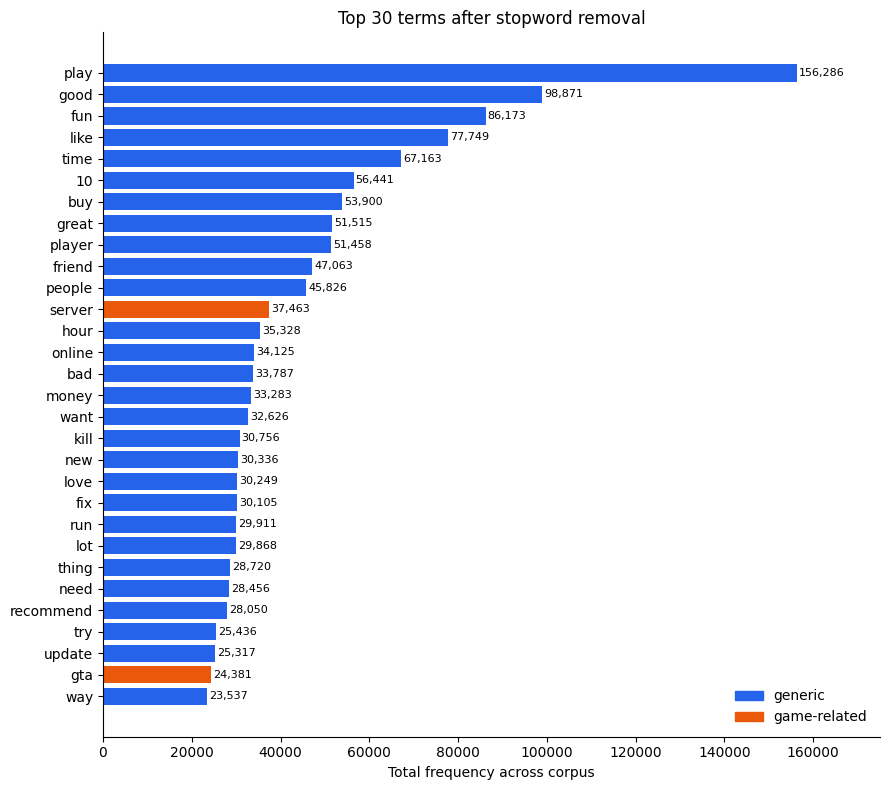

In [24]:
game_tokens = {
    'pubg', 'playerunknown', 'battleground', 'gta', 'rockstar',
    'rust', 'rocket', 'league', 'daylight', 'monster', 'hunter',
    'squad', 'loot', 'raid', 'base', 'ball', 'car', 'map', 'server',
}

fig, ax = plt.subplots(figsize=(9, 8))
terms_r = top_terms2[::-1]
counts_r = top_counts2[::-1]
colors = ['#ea580c' if t in game_tokens else '#2563eb' for t in terms_r]

bars = ax.barh(terms_r, counts_r, color=colors)
for bar in bars:
    w = bar.get_width()
    ax.text(w + term_freq2.max() * 0.003, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va='center', ha='left', fontsize=8)

ax.set_xlabel("Total frequency across corpus")
ax.set_title(f"Top {TOP_K} terms after stopword removal")
ax.set_xlim(0, top_counts2[0] * 1.12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(color='#2563eb', label='generic'),
                   Patch(color='#ea580c', label='game-related')],
          loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

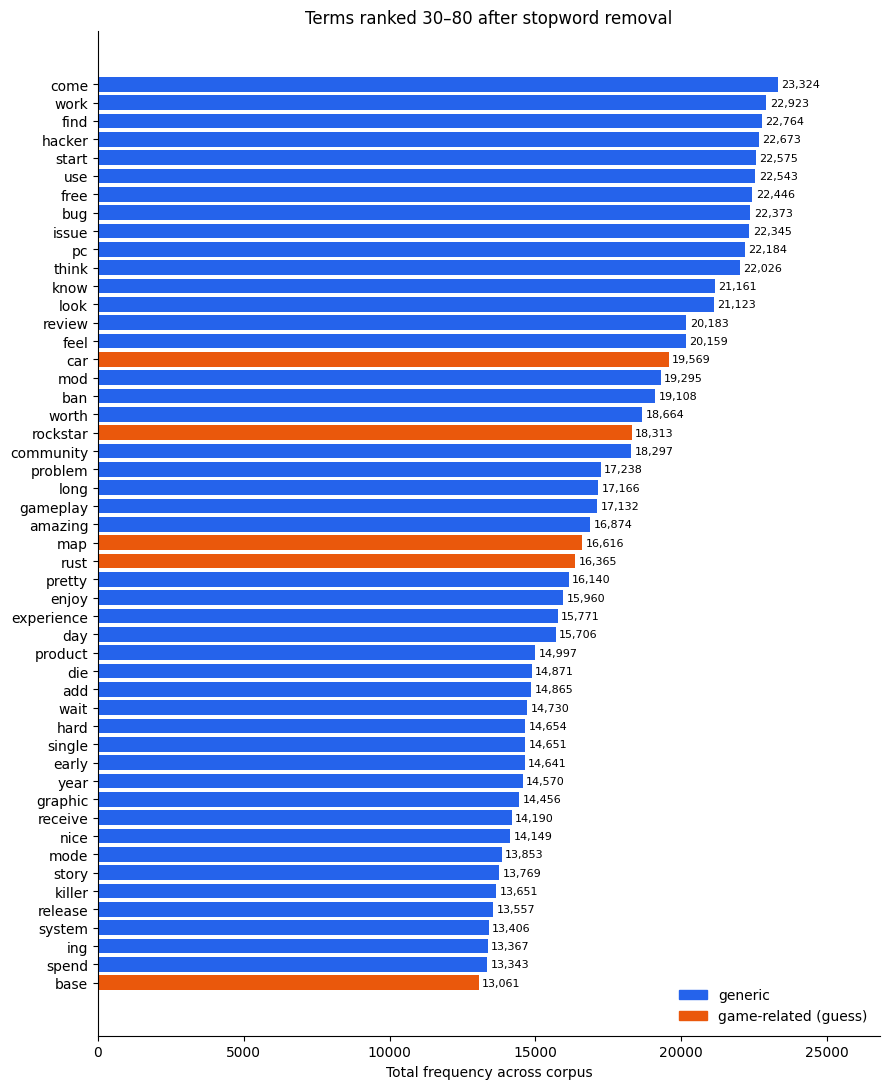

In [25]:
# Look deeper: ranks 30–80. The most frequent terms were mostly generic/thematic;
# game-specific vocabulary likely clusters just below the top.
START, END = 30, 80
deep_idx = np.argsort(term_freq2)[::-1][START:END]
deep_terms = vocab2[deep_idx]
deep_counts = term_freq2[deep_idx]

fig, ax = plt.subplots(figsize=(9, 11))
terms_r = deep_terms[::-1]
counts_r = deep_counts[::-1]
colors = ['#ea580c' if t in game_tokens else '#2563eb' for t in terms_r]

bars = ax.barh(terms_r, counts_r, color=colors)
for bar in bars:
    w = bar.get_width()
    ax.text(w + deep_counts.max() * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va='center', ha='left', fontsize=8)

ax.set_xlabel("Total frequency across corpus")
ax.set_title(f"Terms ranked {START}–{END} after stopword removal")
ax.set_xlim(0, deep_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(color='#2563eb', label='generic'),
                   Patch(color='#ea580c', label='game-related (guess)')],
          loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

In [26]:
# Conservative leakage handling:
# remove only game/brand names. 
# Borderline terms (server, map, mod, ban,
# hacker, base, car, ...) are kept — we'll check later whether they actually
# pull topics toward specific games before deciding to remove them.

game_names = {
    'gta', 'rockstar',          # GTA V
    'pubg', 'playerunknown',    # PUBG
    'rust',                     # Rust
    'rocket', 'league',         # Rocket League (note: 'league' is borderline, but here name-level)
    'daylight',                 # Dead by Daylight
}

# Final stopword set = generic stopwords + obvious domain words + game names.
final_stopwords = set(nlp.Defaults.stop_words) | {'game', 'play', 'player'} | game_names
print(f"Final stopword list size: {len(final_stopwords)}")

Final stopword list size: 337


### 6.3 Parameters & vectorizer construction

In [27]:
# Stopwords removed the *frequent* noise but barely shrank the vocabulary (174k → 173.8k).
# The 173k rare words (typos, one-off names) are the real bloat. We use `min_df` to cut them.
# First we look at the document-frequency distribution to justify the threshold from the data.

# Document frequency = in how many documents each term appears (not total count).
# Reuse the stopword-filtered diagnostic DTM from 6b.

doc_freq = np.asarray((diag_dtm2 > 0).sum(axis=0)).flatten()

# How much of the vocabulary is extremely rare?
for thresh in [1, 2, 5, 10, 20]:
    n_below = (doc_freq <= thresh) .sum()
    print(f"Terms in <= {thresh:>2} documents: {n_below:>7,}  ({n_below/len(doc_freq):.1%} of vocab)")

Terms in <=  1 documents: 120,944  (69.6% of vocab)
Terms in <=  2 documents: 137,672  (79.2% of vocab)
Terms in <=  5 documents: 152,137  (87.5% of vocab)
Terms in <= 10 documents: 158,928  (91.4% of vocab)
Terms in <= 20 documents: 163,635  (94.1% of vocab)


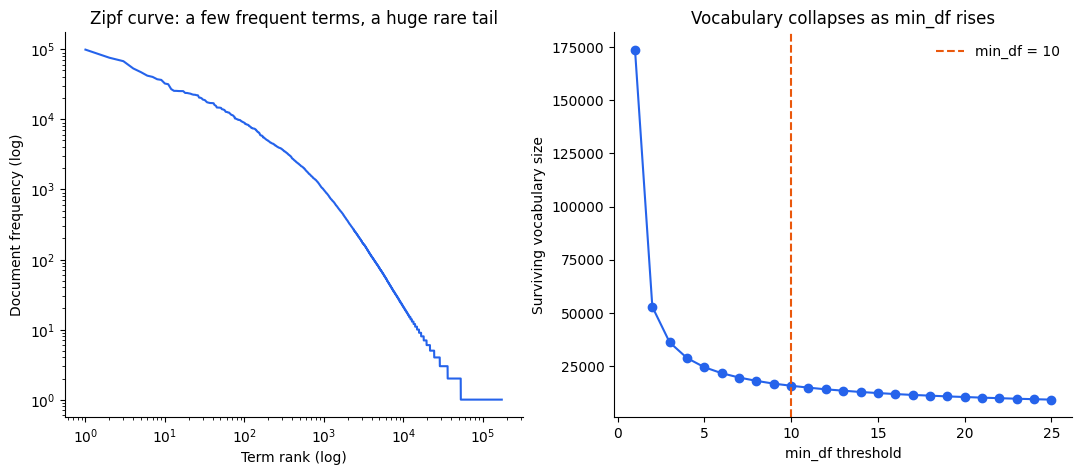

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the classic Zipf curve (rank vs. document frequency, log-log)
sorted_df = np.sort(doc_freq)[::-1]  # descending
ranks = np.arange(1, len(sorted_df) + 1)

axes[0].loglog(ranks, sorted_df, color='#2563eb')
axes[0].set_xlabel("Term rank (log)")
axes[0].set_ylabel("Document frequency (log)")
axes[0].set_title("Zipf curve: a few frequent terms, a huge rare tail")
axes[0].spines[['top', 'right']].set_visible(False)

# Right: how much vocabulary survives each min_df threshold
thresholds = np.arange(1, 26)
surviving = [(doc_freq >= t).sum() for t in thresholds]

axes[1].plot(thresholds, surviving, marker='o', color='#2563eb')
axes[1].axvline(10, color='#ea580c', linestyle='--', label='min_df = 10')
axes[1].set_xlabel("min_df threshold")
axes[1].set_ylabel("Surviving vocabulary size")
axes[1].set_title("Vocabulary collapses as min_df rises")
axes[1].legend(frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

VECT_PARAMS = dict(
    stop_words = list(final_stopwords),
    min_df = 10, # term must appear in at least >= 10 docs
    max_df = 0.5, # drop terms in > 50% docs
    ngram_range = (1,1), # unigram only; topic modeling does not need bigrams
)

count_vectorizer = CountVectorizer(**VECT_PARAMS)
count_dtm = count_vectorizer.fit_transform(data_topic['review_lemmatized'])

tfidf_vectorizer = TfidfVectorizer(**VECT_PARAMS)
tfidf_dtm = tfidf_vectorizer.fit_transform(data_topic['review_lemmatized'])


# Both share the same vocab
print(f'Count DTM: {count_dtm.shape}')
print(f'TF-IDF DTM: {tfidf_dtm.shape}')
print(f'Vocab size: {len(count_vectorizer.get_feature_names_out()):,}')

empty_docs = (count_dtm.sum(axis = 1) == 0).sum()
print(f'Empty docs after vectorizing: {empty_docs:,}')

c:\Users\adris\Desktop\Data_Science_Projects\steam_reviews_nlp\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Count DTM: (318442, 15754)
TF-IDF DTM: (318442, 15754)
Vocab size: 15,754
Empty docs after vectorizing: 1,535


In [ ]:
# Remove 1,535 docs that became empty after stopword + min_df filtering

non_empty = np.asarray(count_dtm.sum(axis = 1)).flatten() > 0
print(f'Before: {count_dtm.shape[0]:,} docs.')


count_dtm = count_dtm[non_empty]
tfidf_dtm = tfidf_dtm[non_empty]
data_topic = data_topic[non_empty].reset_index(drop = True)#

print(f'After: {count_dtm.shape[0]:,} docs (-{(~non_empty).sum():,})')
print(f'Shapes aligned: {count_dtm.shape[0] == tfidf_dtm.shape[0] == len(data_topic)}')

## 7. Choosing the number of topics (k)


In [31]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

tokenized_texts = [doc.split() for doc in data_topic['review_lemmatized']]


gensim_dict = Dictionary(tokenized_texts)

In [32]:
print(f'Tokenized docs: {len(tokenized_texts):,}')
print(f'Gensim dictionary size : {len(gensim_dict):,}')

Tokenized docs: 316,907
Gensim dictionary size : 291,143


In [33]:
def top_words_per_topic(model, feature_names, n_top = 10):
    """Extract the top-n words for each topic from a filtered sklearn LDA or NMF model."""

    topics = []
    for topic_weights in model.components_:
        # Indices of the n highest weighted words.
        top_idx = topic_weights.argsort()[-n_top:][::-1]
        topics.append([feature_names[i] for i in  top_idx])
    return topics


def compute_coherence(model, feature_names, texts, dictionary, n_top = 10):
    # Compute coherence for a fitted sklearn topic model via gensim
    topics = top_words_per_topic(model, feature_names, n_top = n_top)
    cm = CoherenceModel(
        topics = topics,
        texts = texts,
        dictionary = dictionary,
        coherence = 'c_v',
    )
    return cm.get_coherence()

In [34]:
import joblib
from sklearn.decomposition import LatentDirichletAllocation, NMF

K_VALUES = [4, 6, 8, 10, 12, 15]
COHERENCE_CACHE = '../data/processed_data/coherence_sweap.joblib'

if os.path.exists(COHERENCE_CACHE):
    print('Loading cached coherence sweep.')
    results = joblib.load(COHERENCE_CACHE)
else:
    print('Running k-sweep (fits LDA and NMF for each k)')
    results = {'k': [], 'lda': [], 'nmf': []}

    count_features = count_vectorizer.get_feature_names_out()
    tfidf_features = tfidf_vectorizer.get_feature_names_out()

    for k in tqdm(K_VALUES, desc = 'k-sweep'):
    
        lda = LatentDirichletAllocation(n_components = k, max_iter = 10,
                                        learning_method = 'online', random_state = 42)
        lda.fit(count_dtm)
        lda_coh = compute_coherence(lda, count_features, tokenized_texts, gensim_dict)

        # NMF on TF-IDF
        nmf = NMF(n_components = k, init = 'nndsvd', random_state = 42, max_iter = 200)
        nmf.fit(tfidf_dtm)
        nmf_coh = compute_coherence(nmf, tfidf_features, tokenized_texts, gensim_dict)

        results['k'].append(k)
        results['lda'].append(lda_coh)
        results['nmf'].append(nmf_coh)

    joblib.dump(results, COHERENCE_CACHE)
    print(f"Saved coherence sweep to {COHERENCE_CACHE}")

Loading cached coherence sweep.


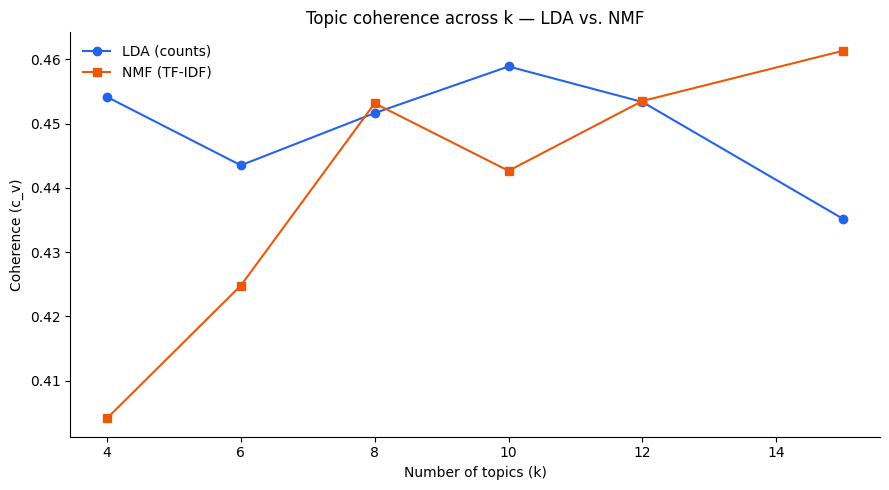

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(results['k'], results['lda'], marker='o', label='LDA (counts)', color='#2563eb')
ax.plot(results['k'], results['nmf'], marker='s', label='NMF (TF-IDF)', color='#ea580c')

ax.set_xlabel("Number of topics (k)")
ax.set_ylabel("Coherence (c_v)")
ax.set_title("Topic coherence across k — LDA vs. NMF")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**DECISION — number of topics.** Read from the coherence curve (c_v) across k ∈ {4,6,8,10,12,15}:

- **LDA: k=10.** Clear coherence peak, falling off at k=12 and 15. Reading the topics confirmed
  10 well-separated, nameable themes.
- **NMF: tested k=8 and k=15.** The curve rose almost monotonically with a local peak at 8 and a
  global max at 15. Rather than pick blindly, both were fit and compared by reading the topics
  (Section 9.1). k=15 won: it split themes that k=8 had merged into distinct, nameable topics,
  worth the mild redundancy.

The coherence values sat in a narrow band (0.40–0.46), so the curve only narrowed the range. The
final choice came from reading the actual topics, not the metric alone.

## 8. Fit final LDA

In [ ]:
# Final LDA and NMF at the chosen k, now with full iterations

BEST_LDA_K = 10 # clear peak from plot
BEST_NMF_K = [8, 15] # local peak vs. global max

FINAL_MODELS_CACHE = '../models/topic_models/final_topic_models.joblib'

if os.path.exists(FINAL_MODELS_CACHE):
    print('Loading cached final models.')
    final = joblib.load(FINAL_MODELS_CACHE)
    lda_final, nmf_final = final['lda'], final['nmf']

else:
    print('Fitting final LDA and NMF')

    lda_final = LatentDirichletAllocation(n_components = BEST_LDA_K, max_iter = 50,
                                          learning_method = 'online', random_state = 42,
                                          verbose = 1, evaluate_every = 5)
    lda_final.fit(count_dtm)

    nmf_final = {}
    for k in BEST_NMF_K:
        nmf = NMF(n_components = k, init = 'nndsvd',
                        random_state = 42, max_iter = 400,
                        verbose = True)
        nmf.fit(tfidf_dtm)
        nmf_final[k] = nmf

    joblib.dump({'lda': lda_final, 'nmf': nmf_final}, FINAL_MODELS_CACHE)
    print('Saved final models to', FINAL_MODELS_CACHE)

## 9. Inspect & interpret topics

### 9.1 Top words per topic - all models

In [37]:
# First look at the actual themes. We print the top 10 words for each topic across all 
# three models (LDA = 10, NMF k = 8, NMF k = 15) using the helper from Section 7

def print_topics(model, feature_names, model_name, n_top = 10):
    """Print top n words per topic for a fitted LDA or NMF model"""
    print(f"\n{'='*70}\n{model_name}  ({model.components_.shape[0]} topics)\n{'='*70}")
    topics = top_words_per_topic(model, feature_names, n_top = n_top)
    for i, words in enumerate(topics):
        print(f'Topic {i: > 2}: {", ".join(words)}')


count_features = count_vectorizer.get_feature_names_out()
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print_topics(lda_final, count_features, 'LDA (k = 10, counts)')
print_topics(nmf_final[8], tfidf_features, 'NMF (k = 8, TF-IDF)')
print_topics(nmf_final[15], tfidf_features, 'NMF (k = 15, TF-IDF)')


LDA (k = 10, counts)  (10 topics)
Topic  0: community, people, bad, base, killer, like, win, pay, ruin, team
Topic  1: server, fix, update, issue, time, bug, good, problem, fun, work
Topic  2: run, pc, battle, fps, graphic, low, version, lock, optimization, setting
Topic  3: map, shoot, like, weapon, gun, find, new, thing, time, item
Topic  4: fun, friend, great, good, lot, recommend, time, feel, like, gameplay
Topic  5: buy, hour, good, like, worth, time, fun, year, money, want
Topic  6: 10, kill, car, die, monster, rock, guy, build, naked, man
Topic  7: good, free, love, product, receive, nice, ing, awesome, like, key
Topic  8: money, hacker, online, people, single, want, time, waste, spend, hack
Topic  9: ban, mod, support, cheat, use, reason, chinese, steam, openiv, company

NMF (k = 8, TF-IDF)  (8 topics)
Topic  0: like, time, server, people, bad, fix, new, need, update, bug
Topic  1: receive, product, free, nice, awesome, cool, like, skyrim, fortnite, funny
Topic  2: good, prett

**Decision - NMF k: chosen k = 15**

Comparing the two NMF candidates:
- **k = 8** is compact but blends multiple ideas into single topics (e.g. Topic 2 mixes survival / graphic / battle / world).
- **k = 15** separates these into distinct, nameable themes that were merged at k = 8 - e.g. a clean technical/bugs topic (fix, server, bug, lag, crash), a load-time/performance topic (time, waste, crash, loading), and addictiveness topic (fun, addictive, competitive)

k = 15 shows mild redundancy (Topics 6 and 9 both capture Rocket League's car/soccer/football vocab), but the extra topics are overwhelmingly genuine themes rather than noise, so the finer granularity is worth it.

**Note for the leakage check (9.4):** two topics are NOT coherent themes and flag known issues:
- LDA Topic 6 / NMF k = 8 Topic 3 (10, 11, ign, nakes, rock, car) = rating phrase tokens (10/10, IGN scores) mixed with RUST vocab - candidates for a second stopword pass.
- Recurring car / soccer / football / naked / rock clusters confirm the Section 5 vocab level leakage hypothesis.

### 9.2 Leakage check

In [ ]:
# Some topics show recurring game-specific clusters
# To confirm whether these are genuine leakage or coincidence, we read actual reviews containing the suspect
# terms in context 

def show_examples(term, n = 10, width = 200):
    """Print n example reviews containing 'term' to judge it in context"""
    mask = data_topic['review_lemmatized'].str.contains(rf'\b{term}\b', regex = True)
    examples = data_topic.loc[mask, ['title', 'review_clean']].head(n)
    print(f"\n{'='*70}\nTerm: '{term}'  —  appears in {mask.sum():,} reviews\n{'='*70}")
    for _, row in examples.iterrows():
        print(f"[{row['title'][:30]:<30}] {row['review_clean'][:width]}")
        print('-' * 70)

for term in ['naked', ' car', 'soccer', 'rock']:
    show_examples(term)

Read example reviews in context for the suspect terms (naked, car, soccer, rock), checking the
`title` column to tell genuine game leakage from coincidence.

**Findings:**
- **`naked`**, **`car`**, **`rock`** — NOT clean markers. Scattered review humor (naked),
  ambiguous across games (car = DbD mechanic + Rocket League), or incidental (rock, mostly DbD).
  Keep all three.
- **`soccer`** — genuine Rocket League leakage ("car soccer"). A real marker.

Takeaway: 3 of 4 suspects were not the leakage the top-words implied. Reading in context was
essential — "frequent in one game" ≠ "game marker".

**DECISION — document, don't re-fit.** Leakage is real but narrow: only the Rocket League
cluster (soccer/football/ball) is clean. Topics 6 and 9 (NMF k=15) read as Rocket-League clusters,
not cross-game themes. Left untreated — the Section-5 diagnostic goal (Option A) is met, and
re-fitting the whole pipeline for marginal gain isn't worth it here. Removing car/naked/rock would
destroy real signal. Second iteration (remove soccer/football/ball, re-fit) noted as future option.

### 9.3 Naming the topics

Labels for NMF k = 15, read from the top words in 9.1. Topics that are not coherent themes carry a
note instead of a forced label.

| Topic | Label |
|-------|-------|
| 0  | *(diffuse, not nameable)* |
| 1  | Free key / giveaway reviews |
| 2  | Survival / Battle Royale |
| 3  | *(rating phrases "10/10" plus noise)* |
| 4  | Fun / addictiveness |
| 5  | Overall positive / gameplay |
| 6  | Rocket League (leakage) |
| 7  | Price / value for money |
| 8  | Playing with friends / multiplayer |
| 9  | Rocket League (leakage) |
| 10 | Mods / bans (GTA modding drama) |
| 11 | *(overlaps with Topic 5)* |
| 12 | Bugs / technical issues |
| 13 | Load times / wasted time |
| 14 | Performance complaints |

Ten of fifteen topics are clean cross-game themes (1, 2, 4, 5, 7, 8, 10, 12, 13, 14). The corpus
does contain cross-game themes, which answers the notebook's main question. The other five are
leakage (6, 9), rating noise (3), or redundant (11), and each one is accounted for.

Labels for LDA k = 10, to support the comparison in 9.4. Same approach as the NMF naming: topics
that are not coherent themes carry a note instead of a label.

| Topic | Label |
|-------|-------|
| 0 | Toxic community / pay-to-win |
| 1 | Bugs / technical issues |
| 2 | Performance / hardware |
| 3 | Combat / weapons |
| 4 | Positive experience |
| 5 | Price / value / playtime |
| 6 | *(rating phrases plus mixed game vocab)* |
| 7 | Free key / giveaway reviews |
| 8 | Cheating / frustration |
| 9 | Mods / bans (GTA modding drama) |

Nine of ten topics are clean cross-game themes, with one weak topic (6, the rating-and-noise mix
seen in the NMF models too). LDA reaches the core themes (bugs, performance, price, experience,
cheating, mods) with fewer topics and less noise than NMF k=15.

### 9.4 LDA vs. NMF - comparison

Both models started from the same filtered, lemmatized corpus and the same vocabulary
(15,754 terms). They differ only in representation and algorithm: LDA on raw counts, NMF on
TF-IDF, as decided in Section 3.

**What each model produced.**

LDA k = 10 labeled cleanly on 9 of 10 topics, with one weak topic (the rating-and-noise mix).
It covers the core themes (bugs, performance, price, positive experience, cheating, mods) with
little redundancy.

NMF k = 15 labeled cleanly on 10 of 15 topics. It splits some themes more finely than LDA, adding
a separate load-time topic and an addictiveness topic. It pays for that granularity with two
redundant Rocket League clusters, the same rating-noise topic, and one topic that overlaps
another.

**Reading the two together.** They land on almost the same core themes. LDA reaches them with
fewer topics and a higher clean-topic ratio (9/10 vs 10/15). NMF surfaces a few extra themes
worth having, at the cost of more redundancy. I rate the two as roughly equal: LDA wins on
compactness and signal-to-noise, NMF wins on granularity.

**Back to the Section-3 hypothesis.** Section 3 expected TF-IDF plus NMF to fit short review
text better than count-based LDA. The results do not confirm that. LDA stayed competitive and
read as cleanly as NMF, sometimes more so. The lesson holds either way: theory sets the
expectation, the data settles it, and building both is what let us check.

**Choice of main model.** This notebook keeps both models for the comparison above. For the next
phase, LDA k=10 goes forward: it reaches the same core themes with a higher clean-topic ratio
(9/10 vs 10/15) and less redundancy, which makes it easier to read and to build on. NMF k=15
stays saved as the more granular alternative.

### 9.5 Visualize topics

In [39]:
# Horizontal bar charts of the top words per topic (bar length = the word's weight in that topic).
# We show the named topics plus one "noise" topic per model, so the plot also illustrates what an
# incoherent topic looks like rather than hiding it.

def plot_topics(model, feature_names, topic_ids, labels, model_name, n_top = 10, ncols = 3):
    """Grid of per-topic top-word bar charts for selected topics."""
    n = len(topic_ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = np.array(axes).flatten()

    for ax, tid in zip(axes, topic_ids):
        weights = model.components_[tid]
        top_idx = weights.argsort()[-n_top:]  # ascending → smallest at bottom
        words = [feature_names[i] for i in top_idx]
        vals = weights[top_idx]

        ax.barh(words, vals, color='#2563eb')
        ax.set_title(f"Topic {tid}: {labels.get(tid, '')}", fontsize = 10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide any unused subplot cells.
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Top words per topic — {model_name}", fontsize = 13, y = 1.0)
    plt.tight_layout()
    plt.show()

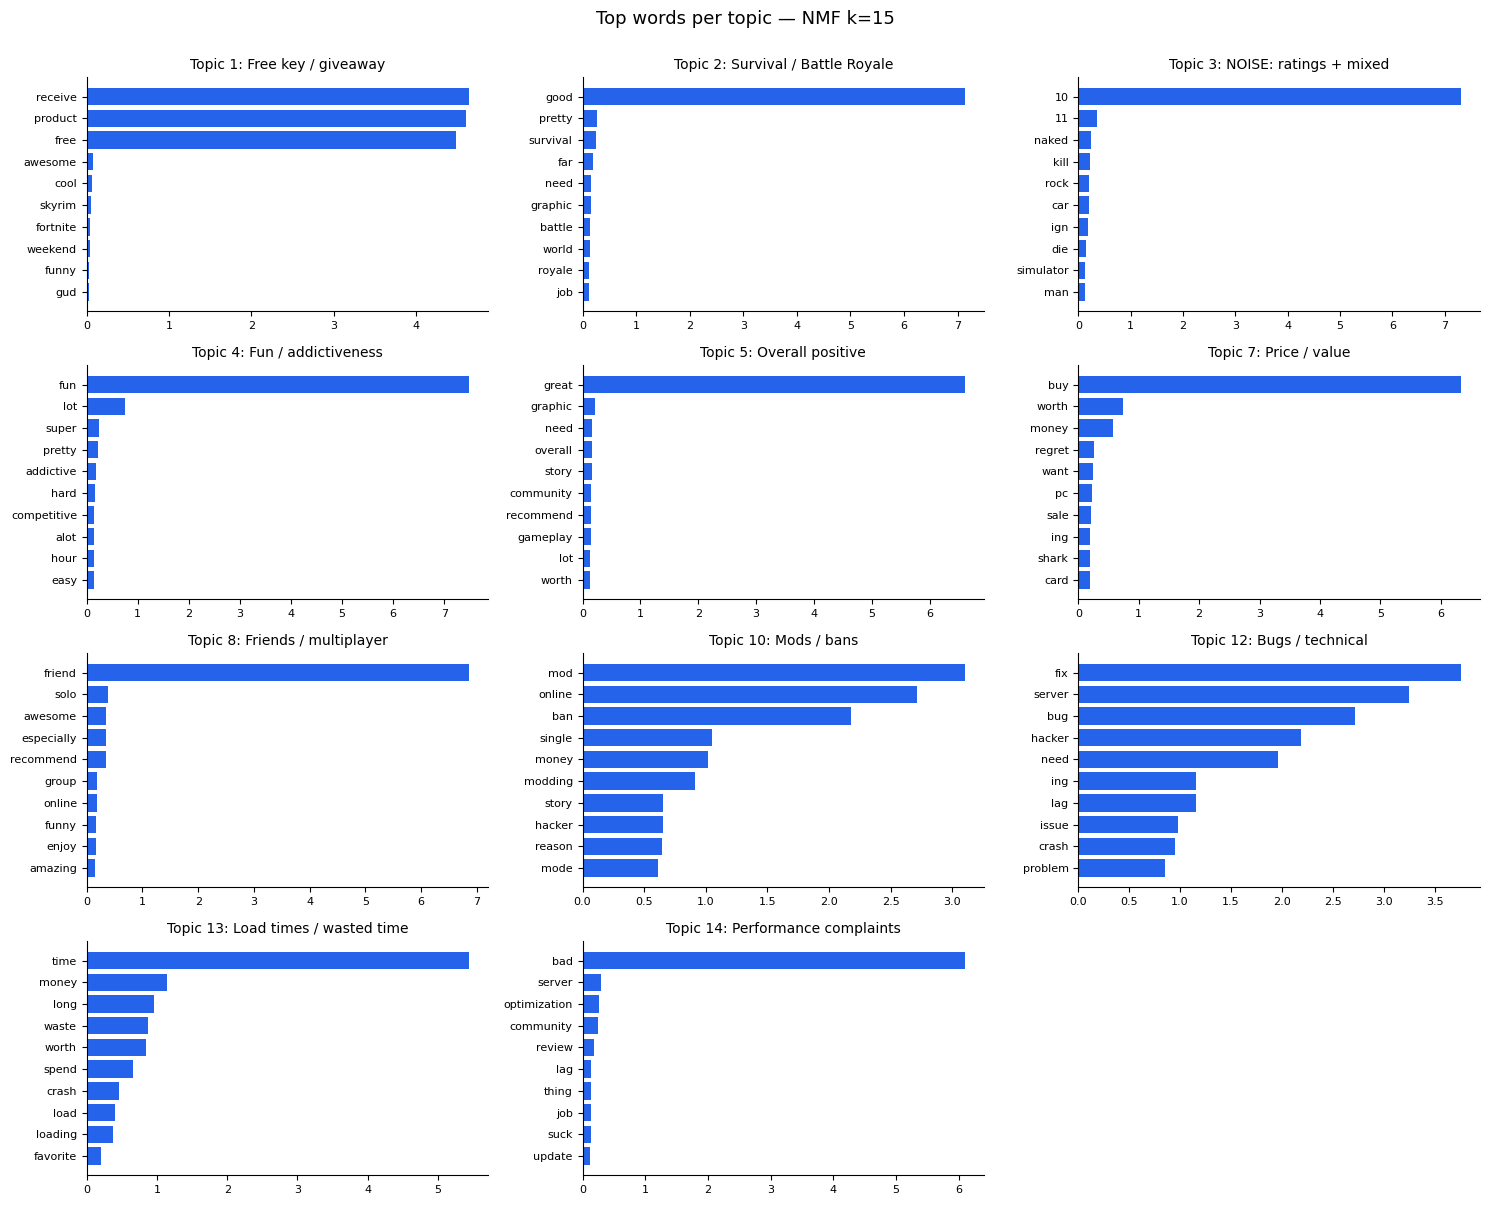

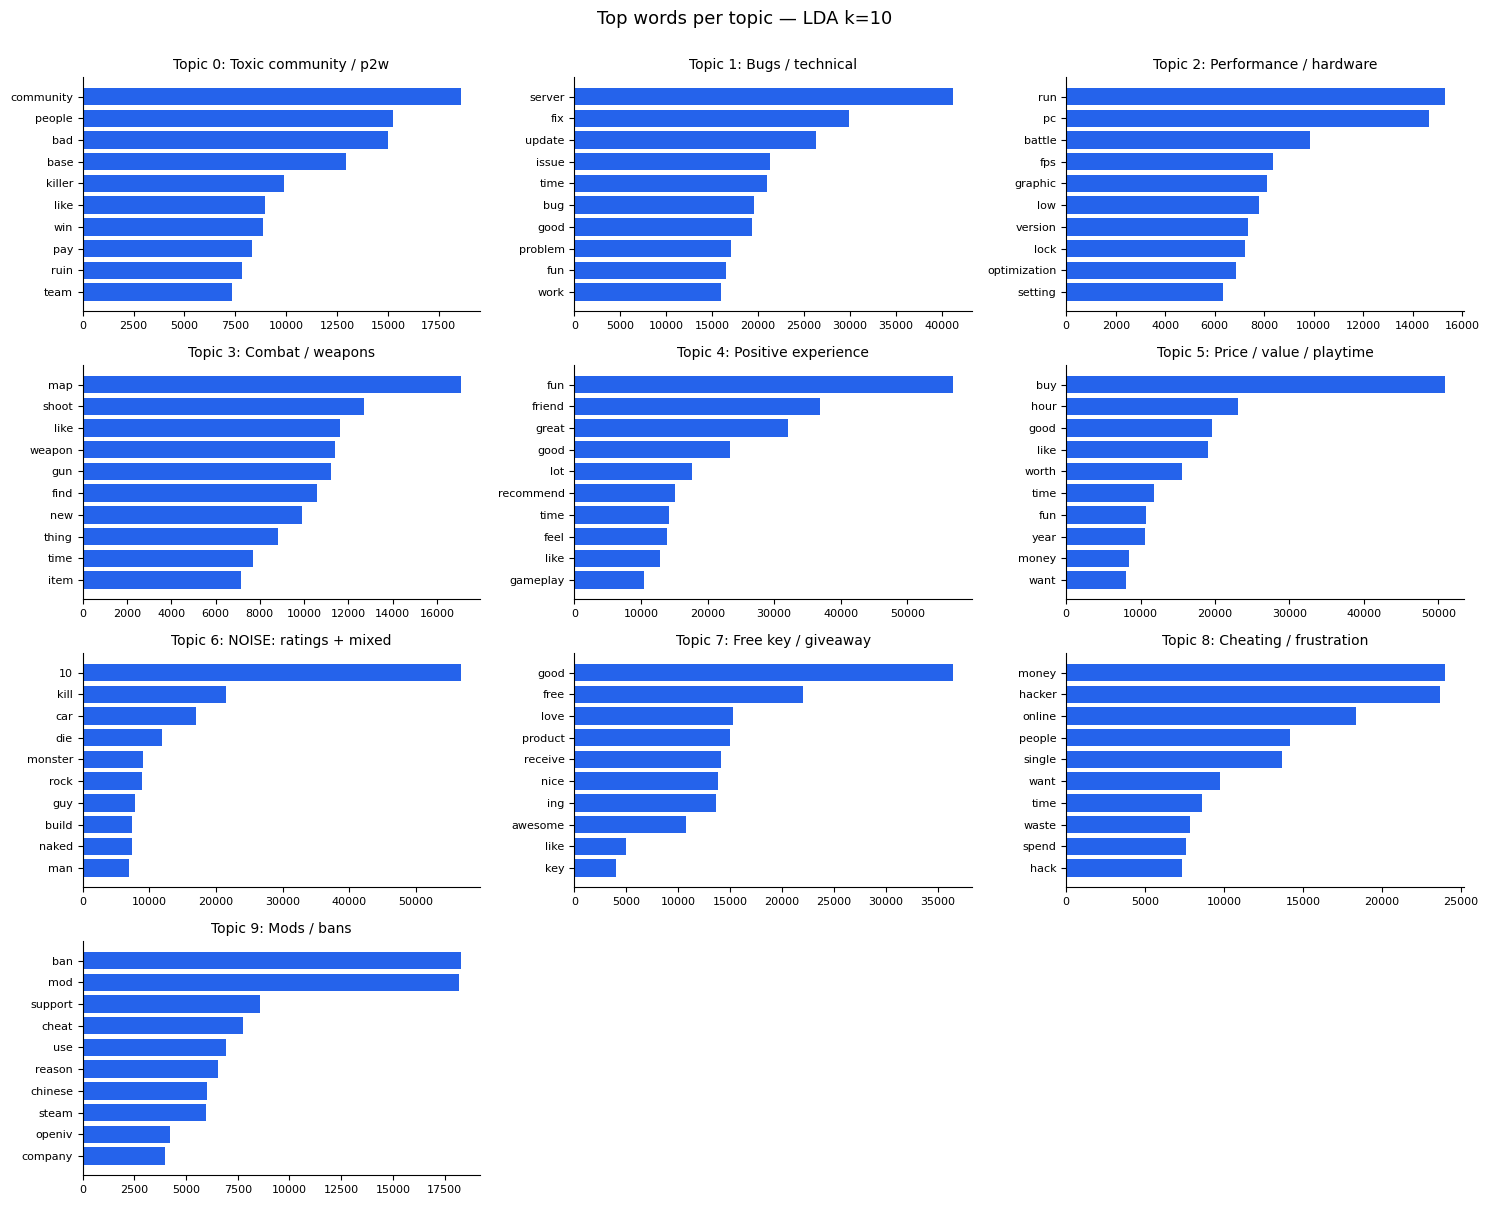

In [40]:
# NMF k=15: named topics + one noise topic (3) for illustration.

nmf_labels = {
    1: 'Free key / giveaway', 2: 'Survival / Battle Royale', 3: 'NOISE: ratings + mixed',
    4: 'Fun / addictiveness', 5: 'Overall positive', 7: 'Price / value',
    8: 'Friends / multiplayer', 10: 'Mods / bans', 12: 'Bugs / technical',
    13: 'Load times / wasted time', 14: 'Performance complaints',
}
plot_topics(nmf_final[15], tfidf_features,
            topic_ids = list(nmf_labels.keys()), labels = nmf_labels,
            model_name = "NMF k=15")

# LDA k=10: named topics + one noise topic (6).
lda_labels = {
    0: 'Toxic community / p2w', 1: 'Bugs / technical', 2: 'Performance / hardware',
    3: 'Combat / weapons', 4: 'Positive experience', 5: 'Price / value / playtime',
    6: 'NOISE: ratings + mixed', 7: 'Free key / giveaway', 8: 'Cheating / frustration',
    9: 'Mods / bans',
}
plot_topics(lda_final, count_features,
            topic_ids=list(lda_labels.keys()), labels = lda_labels,
            model_name = "LDA k=10")

<!-- ### 9.6 Visualizing the topics -->

## 10. Interactive visualization (pyLDAvis)

In [41]:
# Interactive exploration of the LDA model (our main model going forward). Each circle is a topic;
# size = how common the topic is, distance = how distinct topics are from each other. The slider
# (lambda) trades off globally frequent words vs. topic-distinctive words.

import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

# Build the visualization from the fitted sklearn LDA, its count DTM, and the count vectorizer.
lda_vis = pyLDAvis.lda_model.prepare(lda_final, count_dtm, count_vectorizer)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.115941  0.141521       1        1  16.890852
3     -0.094777  0.093155       2        1  14.658743
4      0.200426  0.086012       3        1  14.217195
5      0.156313  0.104140       4        1  12.799970
0     -0.110317  0.105631       5        1   9.066984
8     -0.104302  0.176537       6        1   8.839744
2     -0.081743 -0.285548       7        1   6.774560
6     -0.195012 -0.121725       8        1   6.516780
9     -0.182632 -0.064000       9        1   6.122321
7      0.296104 -0.235724      10        1   4.112851, topic_info=          Term          Freq         Total Category  logprob  loglift
6339      good  98973.000000  98973.000000  Default  30.0000  30.0000
16          10  55639.000000  55639.000000  Default  29.0000  29.0000
2483       buy  53185.000000  53185.000000  Default  28.0000  28.0000
5938       fun  84565.000000  84565.000000  Default  27.0000  27.0000
5816      free  22185.000000  22185.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
9410      need   2345.693022  28517.477821  Topic10  -4.7347   0.6931
9847      open   1672.935040   9999.080305  Topic10  -5.0727   1.4031
1194   amazing   1739.333961  16715.606616  Topic10  -5.0337   0.9282
5367       far   1596.141676  12584.856382  Topic10  -5.1197   1.1261
15442    world   1512.569732  10930.062335  Topic10  -5.1734   1.2133

[559 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
1          6  0.999605      000
16         8  0.999981       10
125        3  0.999867       11
135        4  0.999655       12
166        6  0.999849       15
...      ...       ...      ...
15568      4  0.735582     year
15568      9  0.000069     year
15609      3  0.999349  youtube
15643      7  0.999439   zombie
15645      6  0.999810     zone

[816 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 5, 6, 1, 9, 3, 7, 10, 8])

In [42]:
# Fallback if it doesn't render inline in VS Code:

pyLDAvis.save_html(lda_vis, '../reports/lda_visualization.html')

In [43]:
# Save outputs

OUTPUT_DIR = '../models/topic_models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Main model going forward: LDA + the count vectorizer it depends on.
joblib.dump(lda_final, f'{OUTPUT_DIR}/lda_k10.joblib')
joblib.dump(count_vectorizer, f'{OUTPUT_DIR}/count_vectorizer.joblib')

# Documented alternative: NMF k=15 + its tfidf vectorizer.
joblib.dump(nmf_final[15], f'{OUTPUT_DIR}/nmf_k15.joblib')
joblib.dump(tfidf_vectorizer, f'{OUTPUT_DIR}/tfidf_vectorizer.joblib')

print("Saved models and vectorizers.")

# Doc-topic matrix for LDA: each document's topic distribution.
# Useful later if you want to join topics with sentiment per review.
doc_topic_lda = lda_final.transform(count_dtm)
print(f"Doc-topic matrix shape: {doc_topic_lda.shape}")  # (n_docs, n_topics)

# Save alongside the document identifiers so it can be rejoined to data_topic later.
np.save(f'{OUTPUT_DIR}/doc_topic_lda.npy', doc_topic_lda)
print(f"Saved doc-topic matrix to {OUTPUT_DIR}/doc_topic_lda.npy")

Saved models and vectorizers.
Doc-topic matrix shape: (316907, 10)
Saved doc-topic matrix to ../models/topic_models/doc_topic_lda.npy


In [45]:
# Re-save the doc-topic matrix with its join key (review_clean)

doc_topic_lda = lda_final.transform(count_dtm)

topic_df = data_topic[['review_clean']].copy()
for t in range(doc_topic_lda.shape[1]):
    topic_df[f'topic_{t}'] = doc_topic_lda[:, t]

TOPIC_JOIN_PATH = '../models/topic_models/doc_topic_lda.parquet'
topic_df.to_parquet(TOPIC_JOIN_PATH, index=False)
print(f"Saved with review_clean key: {topic_df.shape}")

Saved with review_clean key: (316907, 11)


In [ ]:
n_rows   = len(topic_df)
n_unique = topic_df['review_clean'].nunique()
print(f"Rows: {n_rows:,}  |  unique: {n_unique:,}")
assert n_rows == n_unique, "review_clean NOT unique -> key broken!"
print("Join key is unique.")

Rows: 316,907  |  unique: 316,907
Join key is unique. Ready for 04.
